# Adaptive Rerank Cutoff: Score-Gap vs Oracle

Given reranked run file(s) and gold relevance judgments, this notebook evaluates
whether reranker **score gaps** predict a good adaptive cutoff for context
generation, compared to an **oracle cutoff** defined by remaining AP mass.

Multiple **rerank sources** (e.g. default workflow vs Gemma reranker) can be compared
side-by-side on the same splits and gold.

**AP definition used here** &mdash; classical AP with denominator R = |gold|:

`FutureGain(k) = (1/R) * sum_{i=k+1}^{N} P@i * rel_i`

This differs from the BioASQ-style `AP@k` (denominator `min(R, k)`) used
elsewhere in this repo. Do **not** compare these numbers directly with MAP@10.

In [10]:
from __future__ import annotations

import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr

try:
    from IPython.display import display
except ImportError:
    display = print  # type: ignore[assignment]

try:
    _NB_DIR = Path(__file__).resolve().parent
except NameError:
    _NB_DIR = Path(".").resolve()
    if not (_NB_DIR / "scripts").exists():
        _NB_DIR = _NB_DIR.parent

REPO_ROOT = _NB_DIR if (_NB_DIR / "scripts").exists() else _NB_DIR.parent
assert (REPO_ROOT / "scripts").exists(), f"Cannot locate repo root (tried {REPO_ROOT})"
sys.path.insert(0, str(REPO_ROOT / "scripts" / "public" / "shared_scripts"))

from retrieval_eval.common import build_topics_and_gold, load_questions

## Configuration

In [11]:
N_CAP = 200
TAU_DEFAULT = 0.05
TAU_GRID = [0.01, 0.02, 0.05, 0.10]

WINDOW_MIN = 3
WINDOW_MAX_FRAC_LIST = [0.5, 0.9]

BUFFER_B = 0
RNG_SEED = 42
SAMPLE_SIZE = 48

# (label, runs_dir) — same analysis is run for each; results tagged with *rerank_source*.
RERANK_RUN_SOURCES: list[tuple[str, Path]] = [
    (
        "baseline",
        REPO_ROOT / "output" / "workflow_baseline_full_run_both_routes" / "rerank" / "runs",
    ),
    (
        "gemma",
        REPO_ROOT / "output" / "workflow_baseline_full_run_both_routes_gemma" / "rerank" / "runs",
    ),
]

GOLD_JSON_MAP: dict[str, Path] = {
    "13B1_golden": REPO_ROOT / "bioasq_data" / "Task13BGoldenEnriched" / "13B1_golden.json",
    "13B2_golden": REPO_ROOT / "bioasq_data" / "Task13BGoldenEnriched" / "13B2_golden.json",
    "13B3_golden": REPO_ROOT / "bioasq_data" / "Task13BGoldenEnriched" / "13B3_golden.json",
    "13B4_golden": REPO_ROOT / "bioasq_data" / "Task13BGoldenEnriched" / "13B4_golden.json",
    "training14b_10pct_sample": REPO_ROOT / "example" / "training14b_10pct_sample.json",
}

N_GOLD_BINS = [(0, 0, "0"), (1, 3, "1-3"), (4, 10, "4-10"), (11, 9999, ">10")]

## Helpers

In [12]:
def load_run_tsv(path: Path, n_cap: int = 200) -> pd.DataFrame:
    """Load rerank run TSV, sort by score desc per qid, truncate to *n_cap*."""
    df = pd.read_csv(path, sep="\t")
    df["score"] = df["score"].astype(float)
    df["docno"] = df["docno"].astype(str)
    df = df.sort_values(["qid", "score"], ascending=[True, False])
    return df.groupby("qid").head(n_cap).reset_index(drop=True)


def load_gold_set_map(json_path: Path) -> dict[str, set[str]]:
    """Return *qid -> set[PMID]* from a BioASQ questions JSON."""
    qs = load_questions(json_path)
    _, gold_lists = build_topics_and_gold(qs)
    return {qid: set(pmids) for qid, pmids in gold_lists.items()}


def future_gain_curve(ranked_docs: list[str], gold: set[str], R: int) -> np.ndarray:
    """FutureGain(k) for k = 0 .. N.  Returns array of length N+1.

    FutureGain(k) = (1/R) * sum of P@i * rel_i for ranks i = k+1 .. N.
    """
    N = len(ranked_docs)
    contribs = np.zeros(N)
    hits = 0
    for i, doc in enumerate(ranked_docs):
        if doc in gold:
            hits += 1
            contribs[i] = (hits / (i + 1)) / R
    fg = np.empty(N + 1)
    fg[N] = 0.0
    acc = 0.0
    for k in range(N - 1, -1, -1):
        acc += contribs[k]
        fg[k] = acc
    return fg


def k_pred_from_gaps(
    scores: np.ndarray, window_min: int, window_max: int,
) -> int:
    """Argmax of score gap g_i = s_i - s_{i+1} over i in [window_min, window_max]
    (1-indexed).  Tie-break: prefer larger i (more conservative cutoff).
    Returns the 1-indexed cutoff position (= prefix length to keep).
    """
    gaps = scores[:-1] - scores[1:]
    lo = max(window_min - 1, 0)
    hi = min(window_max - 1, len(gaps) - 1)
    if lo > hi:
        return window_min
    wg = gaps[lo : hi + 1]
    best = np.where(wg == wg.max())[0][-1]
    return lo + best + 1


def k_oracle_from_tau(fg: np.ndarray, tau: float) -> int:
    """min { k in 0..N : FutureGain(k) <= tau }."""
    idxs = np.where(fg <= tau)[0]
    return int(idxs[0]) if len(idxs) else len(fg) - 1


def _split_from_stem(stem: str) -> str | None:
    # Non-greedy so stems like best_rrf_13B1_golden_top5000_rrf_pool... still yield 13B1_golden.
    m = re.match(r"best_rrf_(.+?)_top\d+", stem)
    return m.group(1) if m else None

## 1. Load Data & Compute Per-Query Metrics

In [13]:
all_records: list[dict] = []
query_arrays: dict[tuple[str, str, str], dict] = {}

for run_label, runs_dir in RERANK_RUN_SOURCES:
    if not runs_dir.is_dir():
        print(f"[skip] {run_label}: missing directory {runs_dir.relative_to(REPO_ROOT)}")
        continue
    run_files = sorted(runs_dir.glob("best_rrf_*_top*.tsv"))
    print(f"\n=== rerank_source={run_label} ===")
    print(f"  Run files: {len(run_files)} in {runs_dir.relative_to(REPO_ROOT)}")

    for rp in run_files:
        split = _split_from_stem(rp.stem)
        if split is None:
            print(f"  skip {rp.name} (cannot parse split)")
            continue
        gp = GOLD_JSON_MAP.get(split)
        if gp is None or not gp.exists():
            print(f"  skip {split}: gold JSON not found")
            continue

        rdf = load_run_tsv(rp, N_CAP)
        gmap = load_gold_set_map(gp)

        common = sorted(set(rdf["qid"].unique()) & set(gmap))
        print(f"  {split}: {len(common)} queries (dropped {len(gmap) - len(common)} gold-only)")

        for qid in common:
            qdf = rdf[rdf["qid"] == qid]
            scores = qdf["score"].values.copy()
            docs = qdf["docno"].values.tolist()
            gold = gmap.get(qid, set())
            R, N = len(gold), len(scores)

            fg = future_gain_curve(docs, gold, R) if R > 0 else np.zeros(N + 1)
            query_arrays[(run_label, split, qid)] = dict(scores=scores, fg=fg, docs=docs)

            rec: dict = dict(
                rerank_source=run_label,
                split=split,
                qid=qid,
                n_gold=R,
                n_docs=N,
                ap_total=fg[0],
            )

            for wf in WINDOW_MAX_FRAC_LIST:
                wmax = min(int(wf * N), N - 1)
                kp = k_pred_from_gaps(scores, WINDOW_MIN, wmax) if N > WINDOW_MIN else WINDOW_MIN
                kk = min(N, kp + BUFFER_B)
                rec[f"kp_{wf}"] = kp
                rec[f"kk_{wf}"] = kk
                rec[f"fg_kp_{wf}"] = fg[kp]
                rec[f"fg_kk_{wf}"] = fg[kk]

            for tau in TAU_GRID:
                rec[f"ko_{tau}"] = k_oracle_from_tau(fg, tau) if R > 0 else 0

            all_records.append(rec)

df_q = pd.DataFrame(all_records)
print(
    f"\nTotal: {len(df_q)} query-rows, "
    f"{df_q['rerank_source'].nunique()} rerank sources, {df_q['split'].nunique()} splits"
)
df_q.head()


=== rerank_source=baseline ===
  Run files: 5 in output/workflow_baseline_full_run_both_routes/rerank/runs
  13B1_golden: 85 queries (dropped 0 gold-only)
  13B2_golden: 85 queries (dropped 0 gold-only)
  13B3_golden: 85 queries (dropped 0 gold-only)
  13B4_golden: 85 queries (dropped 0 gold-only)
  training14b_10pct_sample: 583 queries (dropped 0 gold-only)

=== rerank_source=gemma ===
  Run files: 5 in output/workflow_baseline_full_run_both_routes_gemma/rerank/runs
  13B1_golden: 85 queries (dropped 0 gold-only)
  13B2_golden: 85 queries (dropped 0 gold-only)
  13B3_golden: 85 queries (dropped 0 gold-only)
  13B4_golden: 85 queries (dropped 0 gold-only)
  training14b_10pct_sample: 583 queries (dropped 0 gold-only)

Total: 1846 query-rows, 2 rerank sources, 5 splits


,rerank_source,split,qid,n_gold,n_docs,ap_total,kp_0.5,kk_0.5,fg_kp_0.5,fg_kk_0.5,kp_0.9,kk_0.9,fg_kp_0.9,fg_kk_0.9,ko_0.01,ko_0.02,ko_0.05,ko_0.1
0,baseline,13B1_golden,65f7741fc4010b4d78000027,3,200,0.555556,14,14,0.000000,0.000000,14,14,0.000000,0.000000,3,3,3,3
1,baseline,13B1_golden,660999a0fdcbea915f00001a,50,200,0.456554,97,97,0.026487,0.026487,97,97,0.026487,0.026487,110,106,75,57
2,baseline,13B1_golden,662154f0b9f8b89d7e000009,28,200,0.128730,3,3,0.057302,0.057302,3,3,0.057302,0.057302,131,37,5,1
3,baseline,13B1_golden,662fc277187cba990d000013,18,200,0.450435,81,81,0.000000,0.000000,133,133,0.000000,0.000000,71,64,53,32
4,baseline,13B1_golden,662fc6aa187cba990d000017,2,200,0.000000,10,10,0.000000,0.000000,10,10,0.000000,0.000000,0,0,0,0


## 2. Aggregate Results (per split x tau x window)

In [14]:
def _build_agg(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for src in df["rerank_source"].unique():
        for split in df["split"].unique():
            ds = df[(df["rerank_source"] == src) & (df["split"] == split) & (df["n_gold"] > 0)]
            if ds.empty:
                continue
            for tau in TAU_GRID:
                ko_vals = ds[f"ko_{tau}"].values
                for wf in WINDOW_MAX_FRAC_LIST:
                    kp = ds[f"kp_{wf}"].values
                    fg = ds[f"fg_kp_{wf}"].values
                    if len(kp) > 2 and kp.std() > 0 and ko_vals.std() > 0:
                        rho, pv = spearmanr(kp, ko_vals)
                    else:
                        rho, pv = np.nan, np.nan
                    rows.append(dict(
                        rerank_source=src,
                        split=split, tau=tau, window=f"{wf}N", n=len(ds),
                        rho=rho, p=pv,
                        mean_FG=fg.mean(), med_FG=np.median(fg),
                        mean_kp=kp.mean(), med_kp=np.median(kp),
                        mean_ko=ko_vals.mean(), med_ko=np.median(ko_vals),
                    ))
    return pd.DataFrame(rows)


df_agg = _build_agg(df_q)

_fmt = dict(rho="{:.3f}", p="{:.1e}",
            mean_FG="{:.4f}", med_FG="{:.4f}",
            mean_kp="{:.1f}", med_kp="{:.0f}",
            mean_ko="{:.1f}", med_ko="{:.0f}")

for src in sorted(df_agg["rerank_source"].unique()):
    for split in sorted(df_agg[df_agg["rerank_source"] == src]["split"].unique()):
        print(f"\n{'=' * 70}\n  rerank_source={src}  |  {split}\n{'=' * 70}")
        sub = df_agg[(df_agg["rerank_source"] == src) & (df_agg["split"] == split)]
        display(sub.drop(columns=["rerank_source", "split"]).style.format(_fmt))


  rerank_source=baseline  |  13B1_golden


,tau,window,n,rho,p,mean_FG,med_FG,mean_kp,med_kp,mean_ko,med_ko
0,0.010000,0.5N,85,0.155,1.6e-01,0.0535,0.0189,26.8,12,68.8,71
1,0.010000,0.9N,85,0.285,8.2e-03,0.0466,0.0057,42.7,13,68.8,71
2,0.020000,0.5N,85,0.292,6.7e-03,0.0535,0.0189,26.8,12,50.6,41
3,0.020000,0.9N,85,0.309,4.0e-03,0.0466,0.0057,42.7,13,50.6,41
4,0.050000,0.5N,85,0.380,3.3e-04,0.0535,0.0189,26.8,12,24.6,15
5,0.050000,0.9N,85,0.396,1.8e-04,0.0466,0.0057,42.7,13,24.6,15
6,0.100000,0.5N,85,0.382,3.1e-04,0.0535,0.0189,26.8,12,11.6,3
7,0.100000,0.9N,85,0.280,9.3e-03,0.0466,0.0057,42.7,13,11.6,3



  rerank_source=baseline  |  13B2_golden


,tau,window,n,rho,p,mean_FG,med_FG,mean_kp,med_kp,mean_ko,med_ko
8,0.010000,0.5N,85,0.394,1.9e-04,0.0683,0.0365,24.1,12,72.1,57
9,0.010000,0.9N,85,0.467,6.6e-06,0.0559,0.0141,43.3,13,72.1,57
10,0.020000,0.5N,85,0.407,1.1e-04,0.0683,0.0365,24.1,12,55.6,41
11,0.020000,0.9N,85,0.460,9.7e-06,0.0559,0.0141,43.3,13,55.6,41
12,0.050000,0.5N,85,0.496,1.4e-06,0.0683,0.0365,24.1,12,29.9,15
13,0.050000,0.9N,85,0.480,3.4e-06,0.0559,0.0141,43.3,13,29.9,15
14,0.100000,0.5N,85,0.427,4.5e-05,0.0683,0.0365,24.1,12,16.0,6
15,0.100000,0.9N,85,0.268,1.3e-02,0.0559,0.0141,43.3,13,16.0,6



  rerank_source=baseline  |  13B3_golden


...

,tau,window,n,rho,p,mean_FG,med_FG,mean_kp,med_kp,mean_ko,med_ko
56,0.010000,0.5N,85,-0.102,3.5e-01,0.1496,0.1027,10.7,5,78.3,75
57,0.010000,0.9N,85,-0.088,4.2e-01,0.1394,0.0957,13.5,5,78.3,75
58,0.020000,0.5N,85,-0.004,9.7e-01,0.1496,0.1027,10.7,5,58.4,49
59,0.020000,0.9N,85,0.021,8.5e-01,0.1394,0.0957,13.5,5,58.4,49
60,0.050000,0.5N,85,-0.011,9.2e-01,0.1496,0.1027,10.7,5,36.0,32
61,0.050000,0.9N,85,0.038,7.3e-01,0.1394,0.0957,13.5,5,36.0,32
62,0.100000,0.5N,85,0.050,6.5e-01,0.1496,0.1027,10.7,5,20.9,18
63,0.100000,0.9N,85,0.117,2.9e-01,0.1394,0.0957,13.5,5,20.9,18



  rerank_source=gemma  |  13B4_golden


,tau,window,n,rho,p,mean_FG,med_FG,mean_kp,med_kp,mean_ko,med_ko
64,0.010000,0.5N,85,-0.058,6.0e-01,0.1903,0.1698,7.1,4,104.3,122
65,0.010000,0.9N,85,-0.057,6.0e-01,0.1883,0.1695,8.1,4,104.3,122
66,0.020000,0.5N,85,-0.144,1.9e-01,0.1903,0.1698,7.1,4,79.7,76
67,0.020000,0.9N,85,-0.143,1.9e-01,0.1883,0.1695,8.1,4,79.7,76
68,0.050000,0.5N,85,-0.203,6.3e-02,0.1903,0.1698,7.1,4,47.2,45
69,0.050000,0.9N,85,-0.202,6.4e-02,0.1883,0.1695,8.1,4,47.2,45
70,0.100000,0.5N,85,-0.153,1.6e-01,0.1903,0.1698,7.1,4,25.3,22
71,0.100000,0.9N,85,-0.151,1.7e-01,0.1883,0.1695,8.1,4,25.3,22



  rerank_source=gemma  |  training14b_10pct_sample


,tau,window,n,rho,p,mean_FG,med_FG,mean_kp,med_kp,mean_ko,med_ko
72,0.010000,0.5N,583,0.016,7.0e-01,0.0731,0.0312,10.4,6,46.1,30
73,0.010000,0.9N,583,0.030,4.7e-01,0.0709,0.0280,13.1,6,46.1,30
74,0.020000,0.5N,583,0.075,7.2e-02,0.0731,0.0312,10.4,6,32.1,18
75,0.020000,0.9N,583,0.094,2.3e-02,0.0709,0.0280,13.1,6,32.1,18
76,0.050000,0.5N,583,0.152,2.3e-04,0.0731,0.0312,10.4,6,16.8,6
77,0.050000,0.9N,583,0.158,1.3e-04,0.0709,0.0280,13.1,6,16.8,6
78,0.100000,0.5N,583,0.137,8.8e-04,0.0731,0.0312,10.4,6,8.4,2
79,0.100000,0.9N,583,0.143,5.4e-04,0.0709,0.0280,13.1,6,8.4,2


## 3. Sensitivity Analysis

**(a)** tau grid per window setting &nbsp;|&nbsp; **(b)** Window ablation at default tau

In [15]:
_pivot_cols = ["split", "tau", "rho", "mean_FG", "med_kp"]
for src in sorted(df_agg["rerank_source"].unique()):
    dsrc = df_agg[df_agg["rerank_source"] == src]
    for wf in WINDOW_MAX_FRAC_LIST:
        print(f"\n--- rerank_source={src}  |  tau sensitivity  (window = {wf}N) ---")
        sub = dsrc[dsrc["window"] == f"{wf}N"][_pivot_cols]
        display(sub.pivot(index="tau", columns="split").round(3))

    print(f"\n--- rerank_source={src}  |  Window ablation  (tau = {TAU_DEFAULT}) ---")
    sub2 = dsrc[dsrc["tau"] == TAU_DEFAULT][["split", "window", "rho", "mean_FG", "med_kp"]]
    display(sub2.pivot(index="window", columns="split").round(3))


--- rerank_source=baseline  |  tau sensitivity  (window = 0.5N) ---


rho                                      \
split 13B1_golden 13B2_golden 13B3_golden 13B4_golden   
tau                                                     
0.01        0.155       0.394       0.084       0.117   
0.02        0.292       0.407       0.145       0.202   
0.05        0.380       0.496       0.184       0.266   
0.10        0.382       0.427       0.204       0.327   

                                   mean_FG                          \
split training14b_10pct_sample 13B1_golden 13B2_golden 13B3_golden   
tau                                                                  
0.01                     0.254       0.054       0.068       0.086   
0.02                     0.264       0.054       0.068       0.086   
0.05                     0.243       0.054       0.068       0.086   
0.10                     0.175       0.054       0.068       0.086   

                                                med_kp              \
split 13B4_golden training14b_10pct_sample 13B1_golden 13B2_golden   
tau                                                                  
0.01        0.087                    0.032        12.0        12.0   
0.02        0.087                    0.032        12.0        12.0   
0.05        0.087                    0.032        12.0        12.0   
0.10        0.087                    0.032        12.0        12.0   

                                                        
split 13B3_golden 13B4_golden training14b_10pct_sample  
tau                                                     
0.01         13.0        17.0                     17.0  
0.02         13.0        17.0                     17.0  
0.05         13.0        17.0                     17.0  
0.10         13.0        17.0                     17.0


--- rerank_source=baseline  |  tau sensitivity  (window = 0.9N) ---


rho                                      \
split 13B1_golden 13B2_golden 13B3_golden 13B4_golden   
tau                                                     
0.01        0.285       0.467       0.119       0.225   
0.02        0.309       0.460       0.187       0.317   
0.05        0.396       0.480       0.215       0.330   
0.10        0.280       0.268       0.232       0.344   

                                   mean_FG                          \
split training14b_10pct_sample 13B1_golden 13B2_golden 13B3_golden   
tau                                                                  
0.01                     0.304       0.047       0.056       0.081   
0.02                     0.285       0.047       0.056       0.081   
0.05                     0.208       0.047       0.056       0.081   
0.10                     0.119       0.047       0.056       0.081   

                                                med_kp              \
split 13B4_golden training14b_10pct_sample 13B1_golden 13B2_golden   
tau                                                                  
0.01        0.059                    0.027        13.0        13.0   
0.02        0.059                    0.027        13.0        13.0   
0.05        0.059                    0.027        13.0        13.0   
0.10        0.059                    0.027        13.0        13.0   

                                                        
split 13B3_golden 13B4_golden training14b_10pct_sample  
tau                                                     
0.01         14.0        38.0                     20.0  
0.02         14.0        38.0                     20.0  
0.05         14.0        38.0                     20.0  
0.10         14.0        38.0                     20.0


--- rerank_source=baseline  |  Window ablation  (tau = 0.05) ---


...

rho                                      \
split 13B1_golden 13B2_golden 13B3_golden 13B4_golden   
tau                                                     
0.01        0.019       0.205      -0.102      -0.058   
0.02        0.014       0.156      -0.004      -0.144   
0.05        0.074       0.092      -0.011      -0.203   
0.10        0.102       0.111       0.050      -0.153   

                                   mean_FG                          \
split training14b_10pct_sample 13B1_golden 13B2_golden 13B3_golden   
tau                                                                  
0.01                     0.016       0.121       0.146        0.15   
0.02                     0.075       0.121       0.146        0.15   
0.05                     0.152       0.121       0.146        0.15   
0.10                     0.137       0.121       0.146        0.15   

                                                med_kp              \
split 13B4_golden training14b_10pct_sample 13B1_golden 13B2_golden   
tau                                                                  
0.01         0.19                    0.073         4.0         5.0   
0.02         0.19                    0.073         4.0         5.0   
0.05         0.19                    0.073         4.0         5.0   
0.10         0.19                    0.073         4.0         5.0   

                                                        
split 13B3_golden 13B4_golden training14b_10pct_sample  
tau                                                     
0.01          5.0         4.0                      6.0  
0.02          5.0         4.0                      6.0  
0.05          5.0         4.0                      6.0  
0.10          5.0         4.0                      6.0


--- rerank_source=gemma  |  tau sensitivity  (window = 0.9N) ---


rho                                      \
split 13B1_golden 13B2_golden 13B3_golden 13B4_golden   
tau                                                     
0.01        0.019       0.205      -0.088      -0.057   
0.02        0.014       0.156       0.021      -0.143   
0.05        0.074       0.092       0.038      -0.202   
0.10        0.102       0.111       0.117      -0.151   

                                   mean_FG                          \
split training14b_10pct_sample 13B1_golden 13B2_golden 13B3_golden   
tau                                                                  
0.01                     0.030       0.121       0.146       0.139   
0.02                     0.094       0.121       0.146       0.139   
0.05                     0.158       0.121       0.146       0.139   
0.10                     0.143       0.121       0.146       0.139   

                                                med_kp              \
split 13B4_golden training14b_10pct_sample 13B1_golden 13B2_golden   
tau                                                                  
0.01        0.188                    0.071         4.0         5.0   
0.02        0.188                    0.071         4.0         5.0   
0.05        0.188                    0.071         4.0         5.0   
0.10        0.188                    0.071         4.0         5.0   

                                                        
split 13B3_golden 13B4_golden training14b_10pct_sample  
tau                                                     
0.01          5.0         4.0                      6.0  
0.02          5.0         4.0                      6.0  
0.05          5.0         4.0                      6.0  
0.10          5.0         4.0                      6.0


--- rerank_source=gemma  |  Window ablation  (tau = 0.05) ---


rho                                      \
split  13B1_golden 13B2_golden 13B3_golden 13B4_golden   
window                                                   
0.5N         0.074       0.092      -0.011      -0.203   
0.9N         0.074       0.092       0.038      -0.202   

                                    mean_FG                          \
split  training14b_10pct_sample 13B1_golden 13B2_golden 13B3_golden   
window                                                                
0.5N                      0.152       0.121       0.146       0.150   
0.9N                      0.158       0.121       0.146       0.139   

                                                 med_kp              \
split  13B4_golden training14b_10pct_sample 13B1_golden 13B2_golden   
window                                                                
0.5N         0.190                    0.073         4.0         5.0   
0.9N         0.188                    0.071         4.0         5.0   

                                                         
split  13B3_golden 13B4_golden training14b_10pct_sample  
window                                                   
0.5N           5.0         4.0                      6.0  
0.9N           5.0         4.0                      6.0

### Cross-source snapshot (default tau, window 0.5N)

In [16]:
_snap = df_agg[(df_agg["tau"] == TAU_DEFAULT) & (df_agg["window"] == "0.5N")][
    ["rerank_source", "split", "rho", "mean_FG", "med_kp", "mean_ko"]
]
if len(_snap) and _snap["rerank_source"].nunique() > 1:
    print(f"\n--- Cross-source: tau={TAU_DEFAULT}, window=0.5N  (Spearman rho) ---")
    display(_snap.pivot(index="split", columns="rerank_source", values="rho").round(3))
    print("--- mean FutureGain(k_pred) ---")
    display(_snap.pivot(index="split", columns="rerank_source", values="mean_FG").round(4))
elif len(_snap):
    print("Only one rerank source loaded; cross-source pivots skipped.")


--- Cross-source: tau=0.05, window=0.5N  (Spearman rho) ---


rerank_source,baseline,gemma
split,,
13B1_golden,0.380,0.074
13B2_golden,0.496,0.092
13B3_golden,0.184,-0.011
13B4_golden,0.266,-0.203
training14b_10pct_sample,0.243,0.152


--- mean FutureGain(k_pred) ---


rerank_source,baseline,gemma
split,,
13B1_golden,0.0535,0.1212
13B2_golden,0.0683,0.1465
13B3_golden,0.0856,0.1496
13B4_golden,0.0870,0.1903
training14b_10pct_sample,0.0317,0.0731


## 4. Stratification by n_gold

In [17]:
def _stratify(df: pd.DataFrame, tau: float = TAU_DEFAULT) -> pd.DataFrame:
    rows = []
    for src in df["rerank_source"].unique():
        for split in df["split"].unique():
            ds = df[(df["rerank_source"] == src) & (df["split"] == split)]
            if ds.empty:
                continue
            for lo, hi, lbl in N_GOLD_BINS:
                sub = ds[(ds["n_gold"] >= lo) & (ds["n_gold"] <= hi)]
                if sub.empty:
                    continue
                v = sub["n_gold"] > 0
                for wf in WINDOW_MAX_FRAC_LIST:
                    kp = sub[f"kp_{wf}"].values
                    ko = sub[f"ko_{tau}"].values
                    fg = sub[f"fg_kp_{wf}"].values
                    kpv, kov = kp[v], ko[v]
                    if len(kpv) > 2 and kpv.std() > 0 and kov.std() > 0:
                        rho, _ = spearmanr(kpv, kov)
                    else:
                        rho = np.nan
                    rows.append(dict(
                        rerank_source=src,
                        split=split, n_gold_bin=lbl, window=f"{wf}N",
                        n=len(sub), rho=rho,
                        mean_FG=fg[v].mean() if v.any() else np.nan,
                        med_kp=np.median(kp),
                    ))
    return pd.DataFrame(rows)


df_st = _stratify(df_q)
_sfmt = dict(rho="{:.3f}", mean_FG="{:.4f}", med_kp="{:.0f}")

for src in sorted(df_st["rerank_source"].unique()):
    for split in sorted(df_st[df_st["rerank_source"] == src]["split"].unique()):
        print(f"\n--- rerank_source={src}  |  {split}  (tau = {TAU_DEFAULT}) ---")
        sub = df_st[(df_st["rerank_source"] == src) & (df_st["split"] == split)]
        display(sub.drop(columns=["rerank_source", "split"]).style.format(_sfmt))


--- rerank_source=baseline  |  13B1_golden  (tau = 0.05) ---


,n_gold_bin,window,n,rho,mean_FG,med_kp
0,1-3,0.5N,27,0.421,0.0008,5
1,1-3,0.9N,27,0.195,0.0002,5
2,4-10,0.5N,16,0.351,0.0197,44
3,4-10,0.9N,16,0.425,0.0164,54
4,>10,0.5N,42,0.211,0.1003,18
5,>10,0.9N,42,0.292,0.0879,24



--- rerank_source=baseline  |  13B2_golden  (tau = 0.05) ---


,n_gold_bin,window,n,rho,mean_FG,med_kp
6,1-3,0.5N,27,0.076,0.0139,6
7,1-3,0.9N,27,0.076,0.0139,6
8,4-10,0.5N,8,0.012,0.0828,8
9,4-10,0.9N,8,0.012,0.0788,8
10,>10,0.5N,50,0.395,0.0954,20
11,>10,0.9N,50,0.224,0.0750,42



--- rerank_source=baseline  |  13B3_golden  (tau = 0.05) ---


...

,n_gold_bin,window,n,rho,mean_FG,med_kp
42,1-3,0.5N,16,0.222,0.0005,4
43,1-3,0.9N,16,0.222,0.0005,4
44,4-10,0.5N,13,0.017,0.0515,10
45,4-10,0.9N,13,0.017,0.0515,10
46,>10,0.5N,56,-0.051,0.2150,5
47,>10,0.9N,56,-0.011,0.1994,5



--- rerank_source=gemma  |  13B4_golden  (tau = 0.05) ---


,n_gold_bin,window,n,rho,mean_FG,med_kp
48,1-3,0.5N,4,-0.056,0.0000,6
49,1-3,0.9N,4,-0.056,0.0000,6
50,4-10,0.5N,6,0.522,0.0529,4
51,4-10,0.9N,6,0.522,0.0529,4
52,>10,0.5N,75,-0.211,0.2114,4
53,>10,0.9N,75,-0.211,0.2092,4



--- rerank_source=gemma  |  training14b_10pct_sample  (tau = 0.05) ---


,n_gold_bin,window,n,rho,mean_FG,med_kp
54,1-3,0.5N,212,0.152,0.0129,6
55,1-3,0.9N,212,0.146,0.0120,6
56,4-10,0.5N,183,0.168,0.0712,6
57,4-10,0.9N,183,0.175,0.0706,6
58,>10,0.5N,188,0.081,0.1429,6
59,>10,0.9N,188,0.122,0.1376,6


## 5. Diagnostic Plots (48 sampled queries per rerank source)

rerank_source=baseline: plotting 48 queries


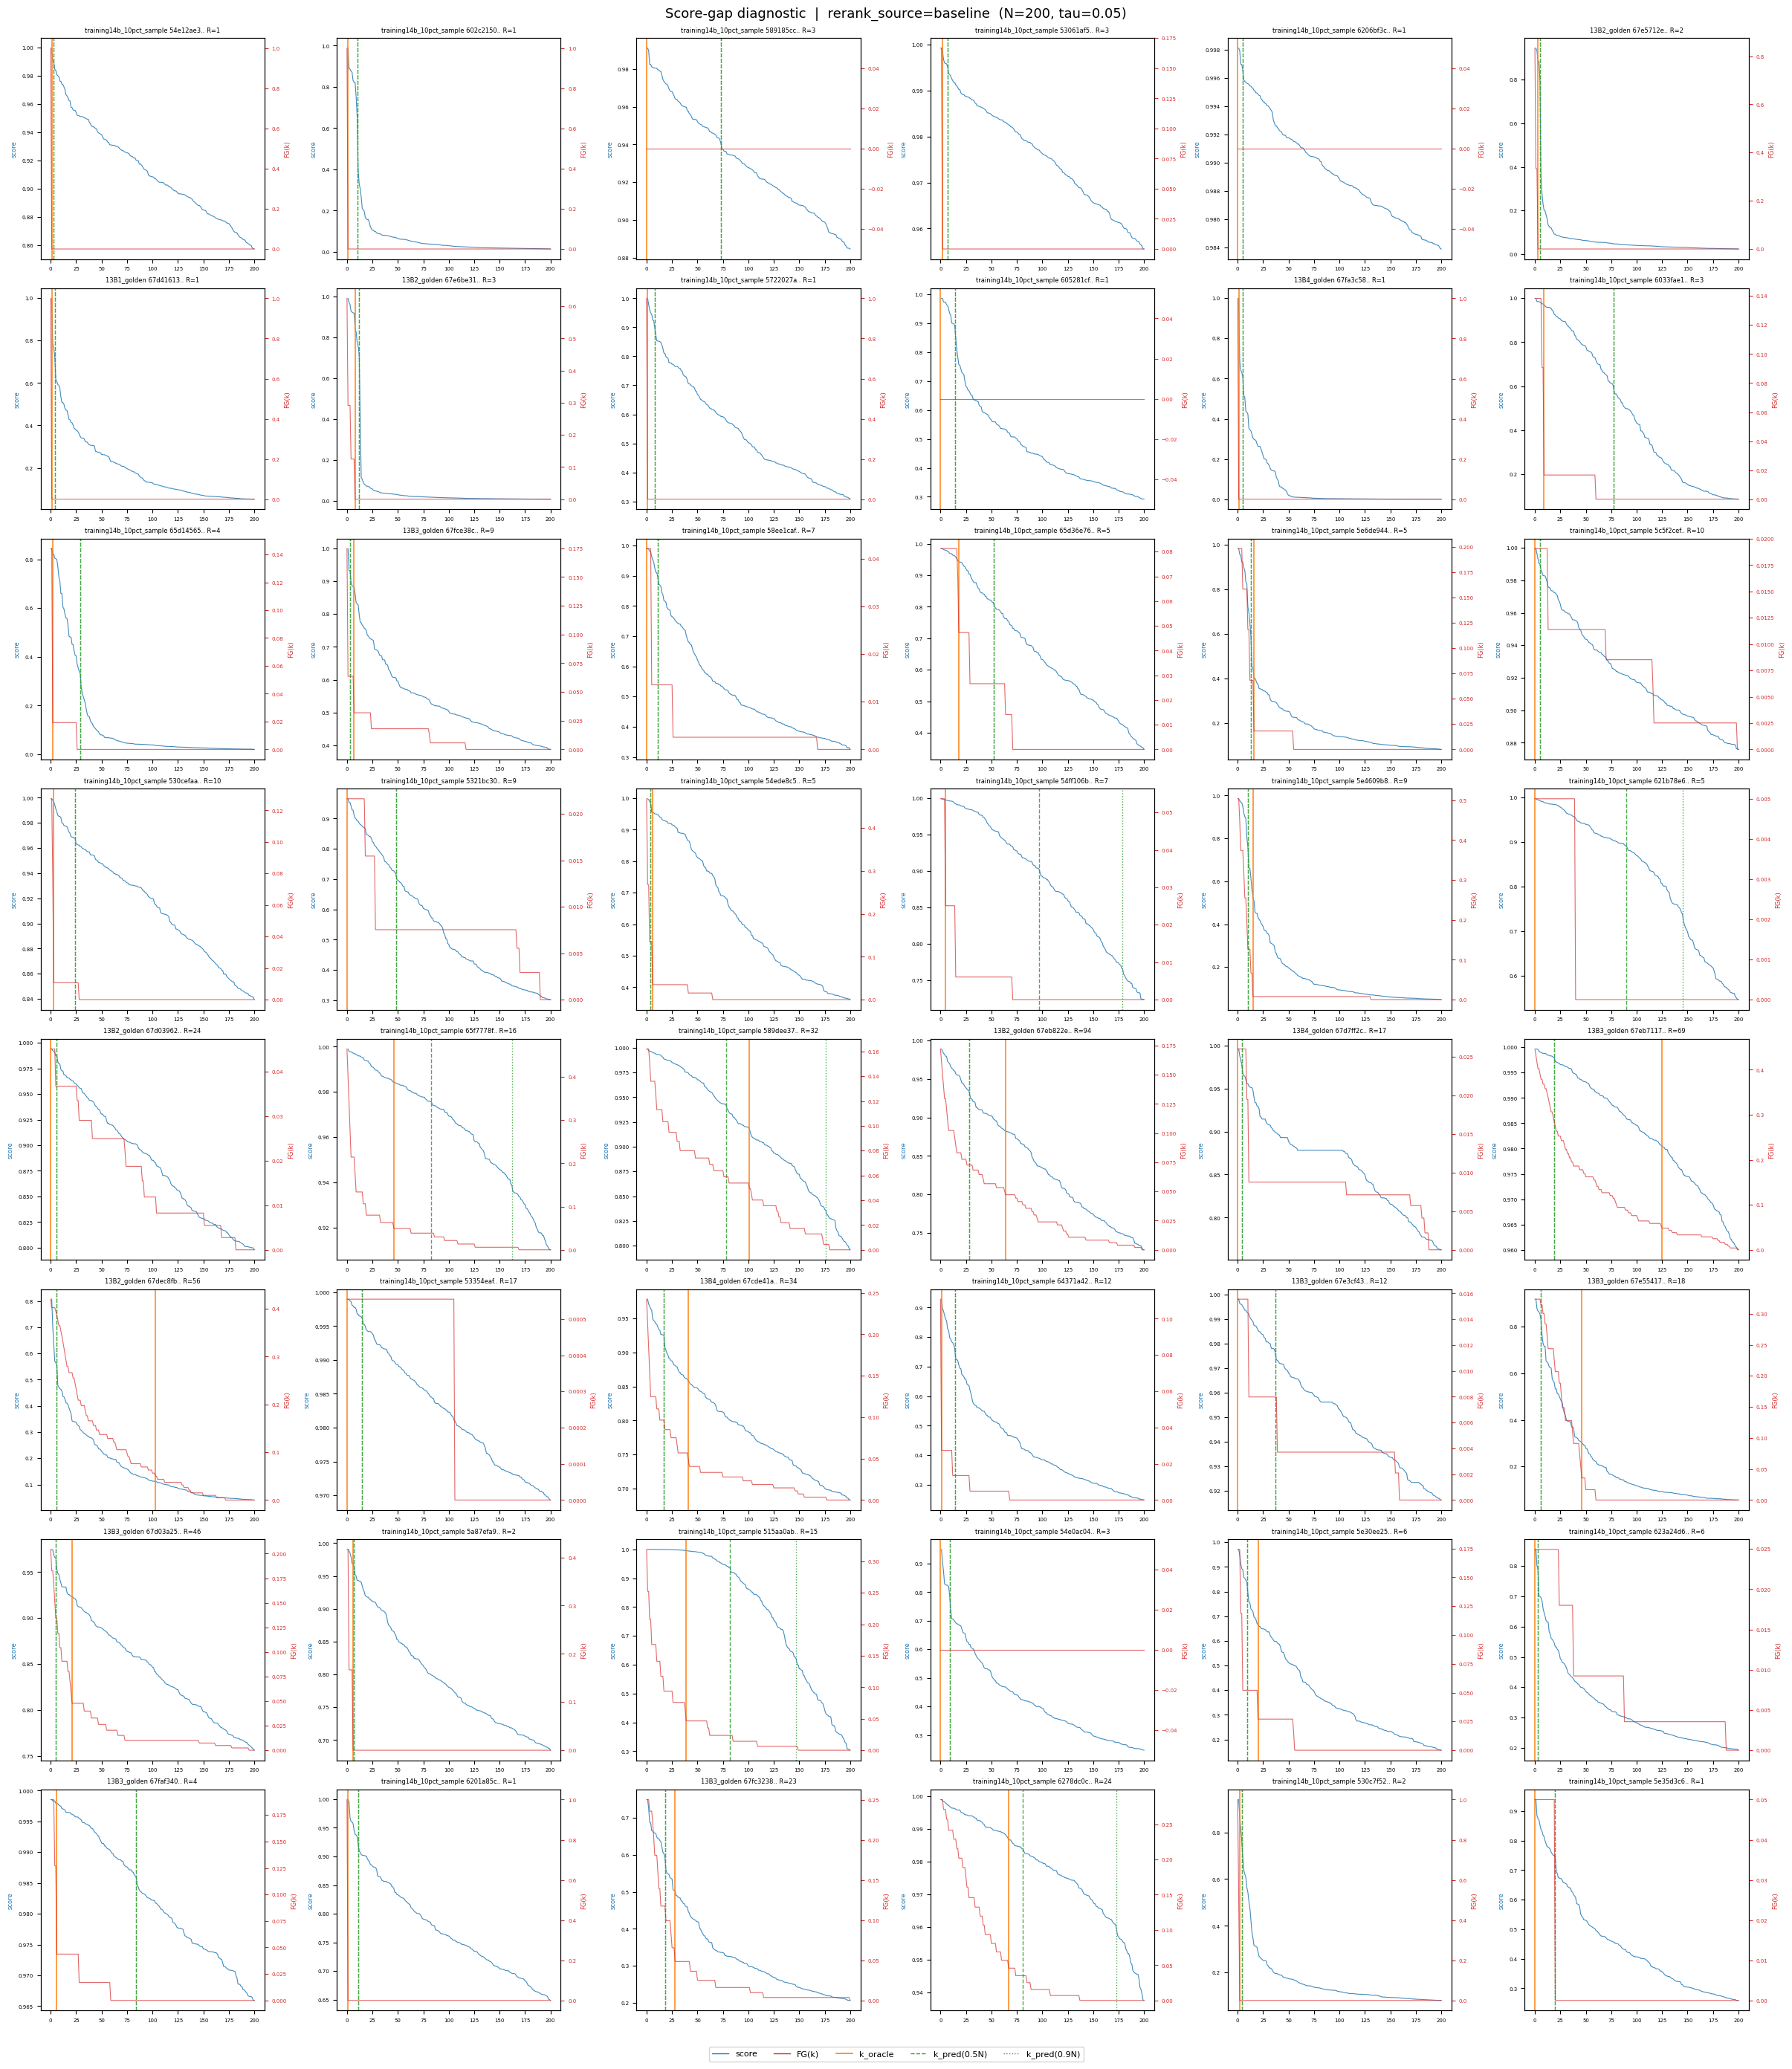

rerank_source=gemma: plotting 48 queries


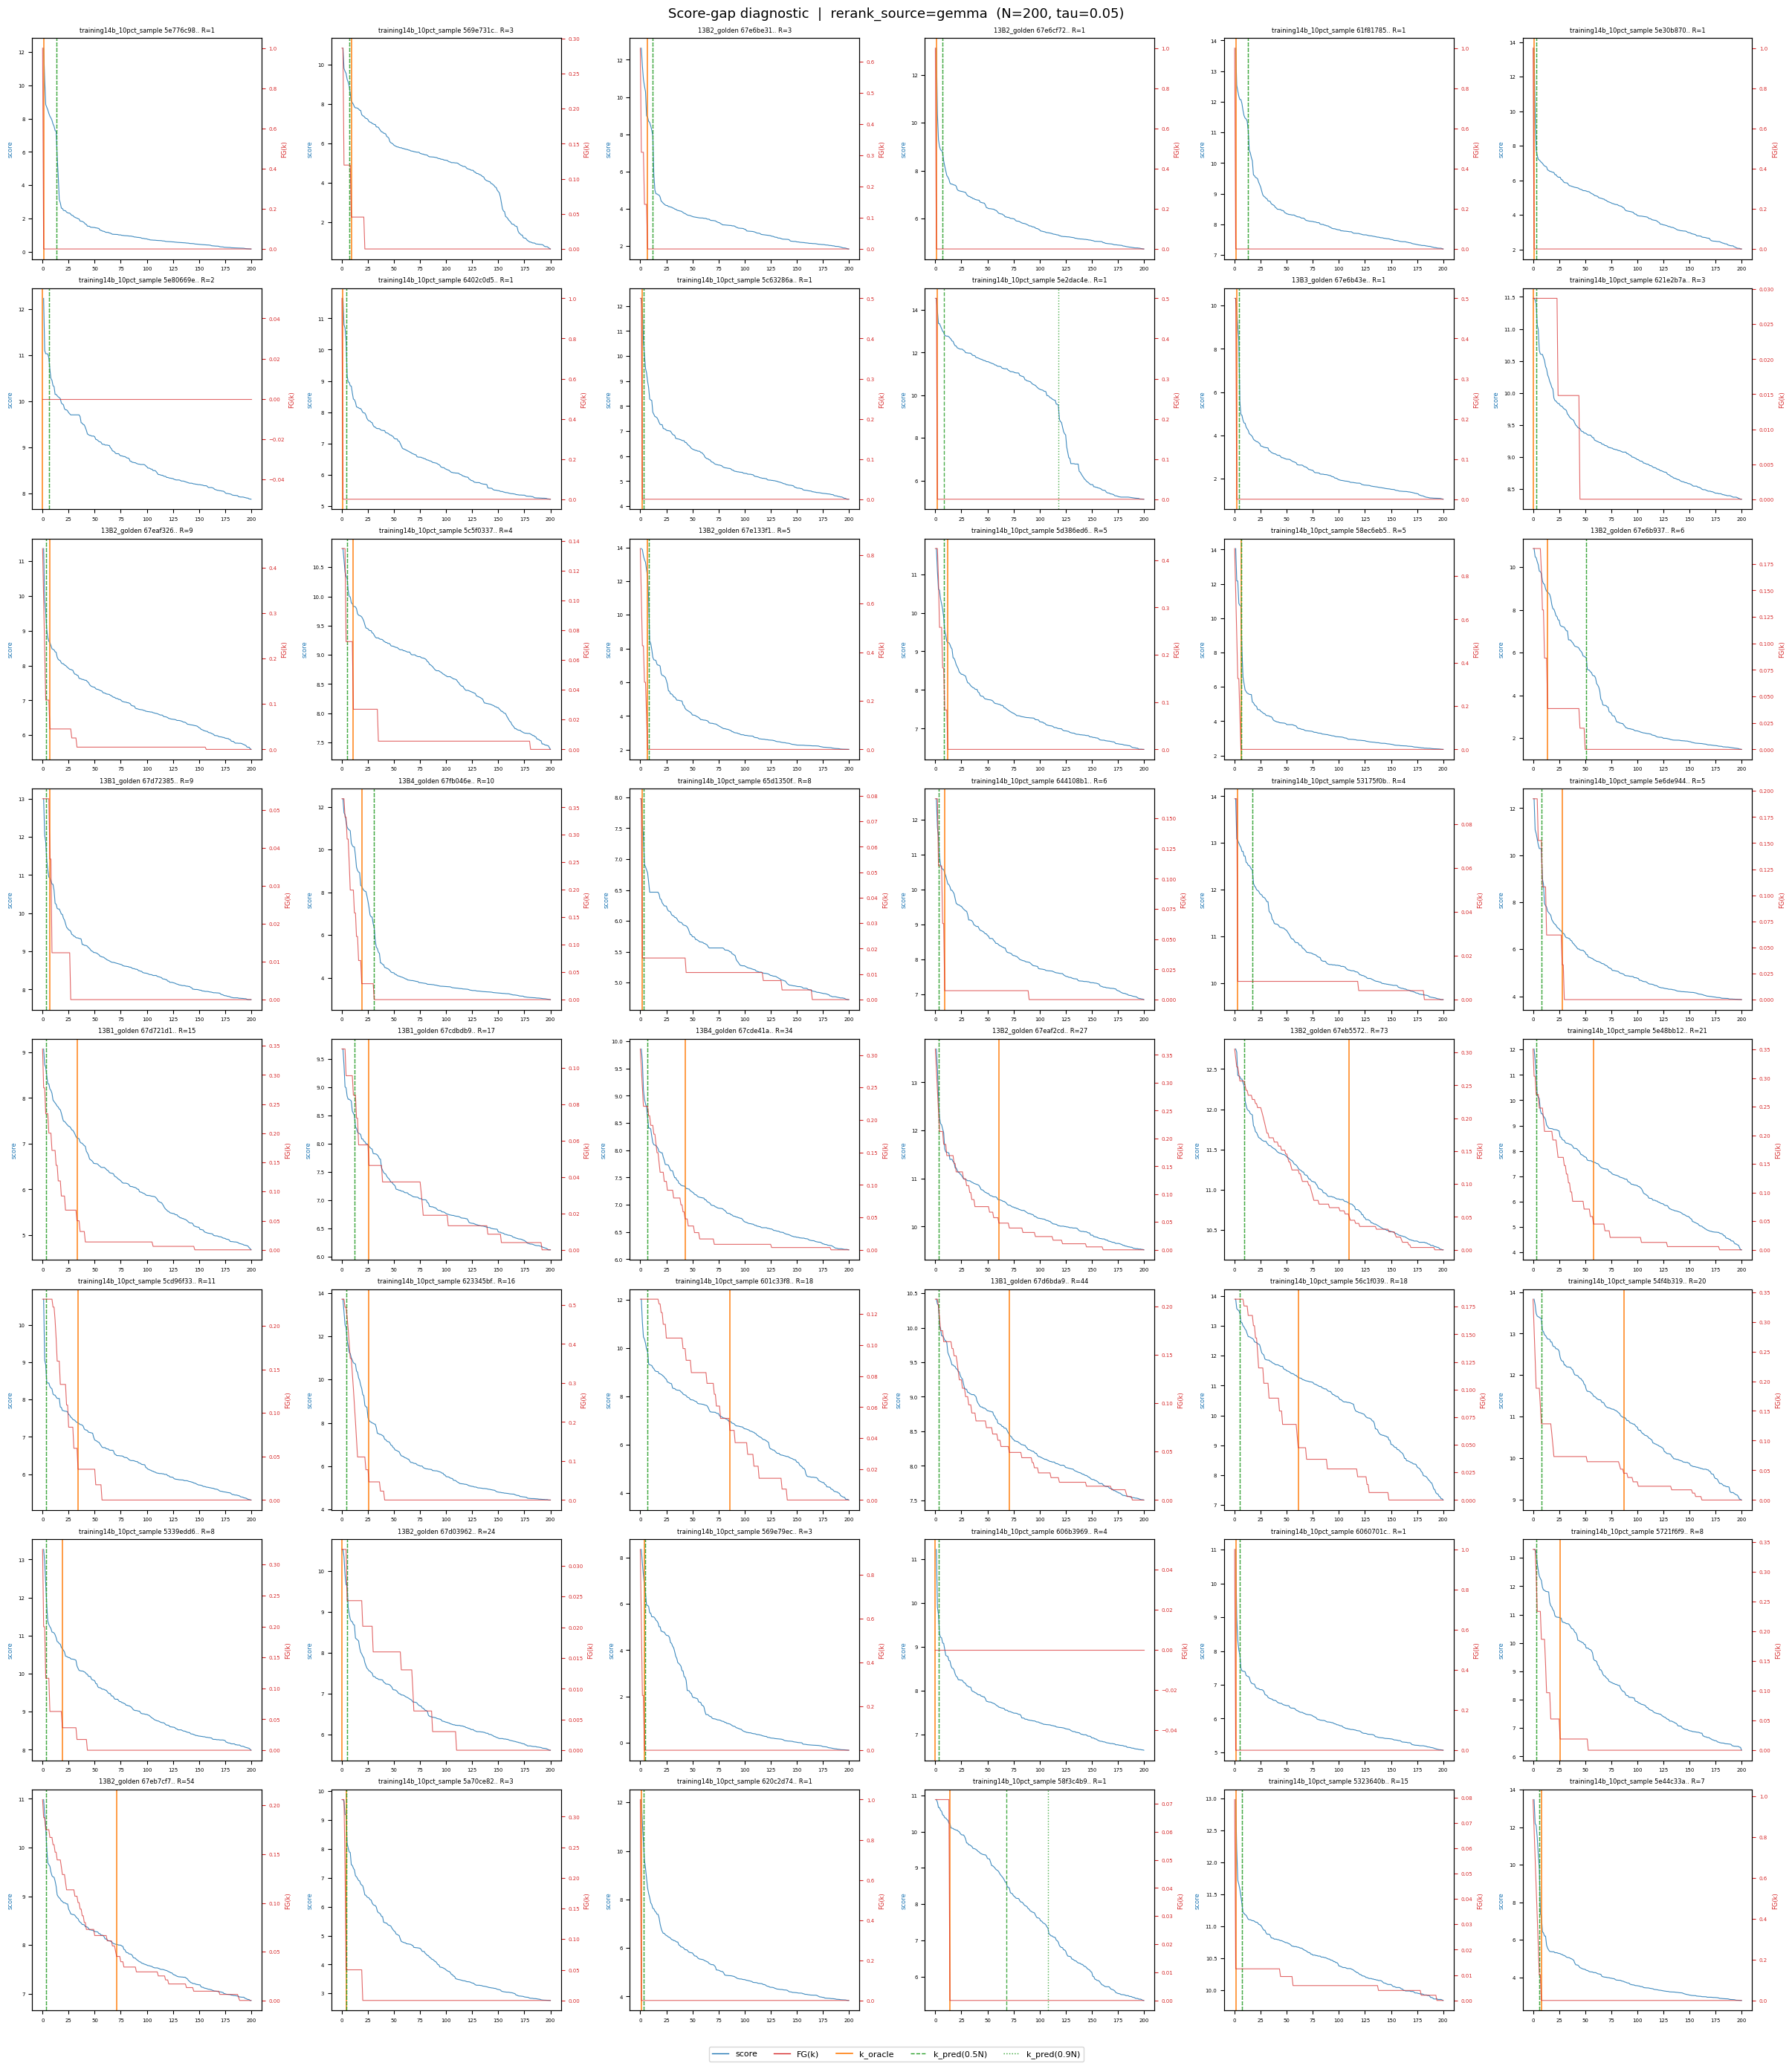

In [18]:
from matplotlib.lines import Line2D

rng = np.random.default_rng(RNG_SEED)
ncols = 6

for run_label in sorted(df_q["rerank_source"].unique()):
    df_pos = df_q[(df_q["n_gold"] > 0) & (df_q["rerank_source"] == run_label)].copy()
    if df_pos.empty:
        print(f"No positive-gold rows for rerank_source={run_label}; skip plots.")
        continue

    sampled: list[tuple[str, str]] = []
    per_bin = max(1, SAMPLE_SIZE // len(N_GOLD_BINS))
    for lo, hi, _ in N_GOLD_BINS:
        pool = df_pos[(df_pos["n_gold"] >= lo) & (df_pos["n_gold"] <= hi)]
        n_take = min(per_bin, len(pool))
        if n_take > 0:
            chosen = pool.sample(n=n_take, random_state=int(rng.integers(1 << 31)))
            sampled.extend(zip(chosen["split"], chosen["qid"]))

    if len(sampled) < SAMPLE_SIZE:
        already = set(sampled)
        rest = df_pos[~df_pos.apply(lambda r: (r["split"], r["qid"]) in already, axis=1)]
        n_extra = min(SAMPLE_SIZE - len(sampled), len(rest))
        if n_extra > 0:
            extra = rest.sample(n=n_extra, random_state=int(rng.integers(1 << 31)))
            sampled.extend(zip(extra["split"], extra["qid"]))

    sampled = sampled[:SAMPLE_SIZE]
    print(f"rerank_source={run_label}: plotting {len(sampled)} queries")

    nrows = (len(sampled) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3.4),
                               constrained_layout=True)
    axf = np.asarray(axes).flatten()

    for idx, (sp, qid) in enumerate(sampled):
        ax = axf[idx]
        arr = query_arrays[(run_label, sp, qid)]
        sc, fg = arr["scores"], arr["fg"]
        Nloc = len(sc)
        m = (df_q["rerank_source"] == run_label) & (df_q["split"] == sp) & (df_q["qid"] == qid)
        rec = df_q[m].iloc[0]
        ranks = np.arange(1, Nloc + 1)

        ax.plot(ranks, sc, color="tab:blue", lw=0.8, alpha=0.85)
        ax.set_ylabel("score", fontsize=6, color="tab:blue")
        ax.tick_params(axis="both", labelsize=5)

        ax2 = ax.twinx()
        ax2.plot(np.arange(Nloc + 1), fg, color="tab:red", lw=0.8, alpha=0.7)
        ax2.set_ylabel("FG(k)", fontsize=6, color="tab:red")
        ax2.tick_params(axis="y", labelsize=5, colors="tab:red")

        ko = rec[f"ko_{TAU_DEFAULT}"]
        ax.axvline(ko, color="tab:orange", ls="-", lw=1.2, alpha=0.9)

        for j, wf in enumerate(WINDOW_MAX_FRAC_LIST):
            kp = rec[f"kp_{wf}"]
            ax.axvline(kp, color="tab:green", ls=("--" if j == 0 else ":"),
                       lw=1.0, alpha=0.85)

        ax.set_title(f"{sp} {qid[:8]}.. R={rec['n_gold']}", fontsize=6)

    for j in range(len(sampled), len(axf)):
        axf[j].set_visible(False)

    handles = [
        Line2D([], [], color="tab:blue", lw=1, label="score"),
        Line2D([], [], color="tab:red", lw=1, label="FG(k)"),
        Line2D([], [], color="tab:orange", ls="-", lw=1.2, label="k_oracle"),
    ]
    for j, wf in enumerate(WINDOW_MAX_FRAC_LIST):
        handles.append(Line2D([], [], color="tab:green", ls=("--" if j == 0 else ":"),
                              lw=1, label=f"k_pred({wf}N)"))
    fig.legend(handles=handles, loc="lower center", ncol=len(handles), fontsize=8,
               bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(
        f"Score-gap diagnostic  |  rerank_source={run_label}  (N={N_CAP}, tau={TAU_DEFAULT})",
        fontsize=13,
    )
    plt.show()

## Conclusion

*(Fill in after running the notebook -- the tables and plots above drive the
interpretation.)*

1. **Spearman rho(k_pred, k_oracle):** Values above ~0.3 indicate moderate
   alignment between the score-gap heuristic and the oracle; below ~0.15 the
   gap signal is effectively uncorrelated.

2. **Residual AP mass -- mean FG(k_pred) vs tau:** If the mean is close to
   tau, the heuristic approximates the oracle budget well.  If it is much
   larger, the cutoff is too aggressive and discards valuable relevant
   documents.

3. **Window ablation (0.5N vs 0.9N):** If rho increases and FG(k_pred)
   decreases when the window widens, the default early-only range was overly
   restrictive and useful deep gaps were being ignored.  If results are
   similar, the gap heuristic is inherently early-biased or stable regardless
   of window width.

4. **n_gold dependence:** Queries with large R (>10 relevant documents) tend
   to accumulate AP mass deep in the list.  The gap heuristic may
   systematically under-retrieve for them -- check the stratified table for
   the ">10" bin.

5. **Multiple rerank sources:** Compare *baseline* vs *gemma* tables for the
   same split and tau.  Oracle cutoffs (*k_oracle*, FG) depend only on ranking
   order of gold docs, which changes when the reranker changes; score-gap
   behavior reflects each model's score calibration.